# Breast Ultrasound Classification
## Reproducible research record

This notebook is a thin, executable view of the repository evidence. It does not contain hand-entered benchmark values. The supplied cohort currently fails its subject-level split audit, so every displayed metric is a **provisional engineering result**, not a clinical-performance estimate.

## 1. Environment and project location

Run the notebook from the repository root after installing `requirements.txt`. The cell records basic runtime information without modifying the environment.

In [1]:
from pathlib import Path
import json, platform, subprocess, sys

ROOT = Path.cwd()
assert (ROOT / "src").is_dir(), "Open this notebook from the dissertation repository root."
print({"python": sys.version.split()[0], "platform": platform.platform(), "project": ROOT.name})

{'python': '3.9.6', 'platform': 'macOS-15.7.7-x86_64-i386-64bit', 'project': 'Dissertation'}


## 2. Audit data integrity

The audit derives subject identifiers where the local filename convention permits and records cross-partition subjects. BUSI is marked unverifiable because the local files were renamed without an original-ID manifest.

In [2]:
subprocess.run(
    [sys.executable, "scripts/audit_data.py", "--output", "outputs/data_audit.json"],
    check=True,
)
audit = json.loads((ROOT / "outputs/data_audit.json").read_text())
audit["audit_passed"], audit["failed_datasets"]

{
  "audit_passed": false,
  "breast": {
    "counts": {
      "test": {
        "benign": 23,
        "malignant": 15,
        "normal": 2
      },
      "train": {
        "benign": 101,
        "malignant": 59,
        "normal": 2
      },
      "val": {
        "benign": 15,
        "malignant": 12
      }
    },
    "cross_split_subjects": {
      "case140": [
        "test",
        "train"
      ],
      "case151": [
        "train",
        "val"
      ]
    },
    "subject_ids_verifiable": true
  },
  "busi": {
    "counts": {
      "test": {
        "benign": 25,
        "malignant": 25
      },
      "train": {
        "benign": 50,
        "malignant": 50
      },
      "val": {
        "benign": 25,
        "malignant": 25
      }
    },
    "cross_split_subjects": {},
    "subject_ids_verifiable": false
  },
  "failed_datasets": [
    "busi",
    "oasbud",
    "breast"
  ],
  "notes": [
    "BUSI filenames were renamed during curation, so patient-level separation cannot b

(False, ['busi', 'oasbud', 'breast'])

In [3]:
import pandas as pd

rows = []
for dataset in ("busi", "oasbud", "breast"):
    for split, labels in audit[dataset]["counts"].items():
        rows.append({"dataset": dataset, "split": split, "images": sum(labels.values())})
pd.DataFrame(rows).pivot(index="dataset", columns="split", values="images").fillna(0).astype(int)

split,test,train,val
dataset,,,
breast,40,162,27
busi,50,100,50
oasbud,30,140,30


## 3. Generate checkpoint evidence

`evaluate.py` uses the shared preprocessing implementation and writes per-image predictions before its aggregate summary. This cell can take several minutes on CPU.

In [4]:
RUN_EVALUATION = False  # Set True to regenerate metrics and plots from the bundled checkpoint.
if RUN_EVALUATION:
    subprocess.run([sys.executable, "evaluate.py", "--split", "test"], check=True)
else:
    print("Using the committed local evidence files; set RUN_EVALUATION=True to regenerate them.")

Using the committed local evidence files; set RUN_EVALUATION=True to regenerate them.


## 4. Inspect generated metrics

The following values come from `outputs/metrics.json`. The audit status is shown alongside them so the evidence boundary cannot be separated from the headline numbers.

In [5]:
metrics = json.loads((ROOT / "outputs/metrics.json").read_text())
summary = pd.DataFrame([metrics["summary"]], index=[metrics["model_name"]])
display(summary.style.format("{:.4f}"))
print({
    "samples": metrics["samples"],
    "split": metrics["split"],
    "evidence_status": metrics.get("evidence_status", "legacy provisional record"),
    "data_audit_passed": metrics.get("data_audit_passed", False),
})

,accuracy,macro_f1,macro_precision,macro_recall,roc_auc
efficientnet_b0,0.7833,0.7811,0.7886,0.7809,0.8612


{'samples': 120, 'split': 'test', 'evidence_status': 'provisional', 'data_audit_passed': False}


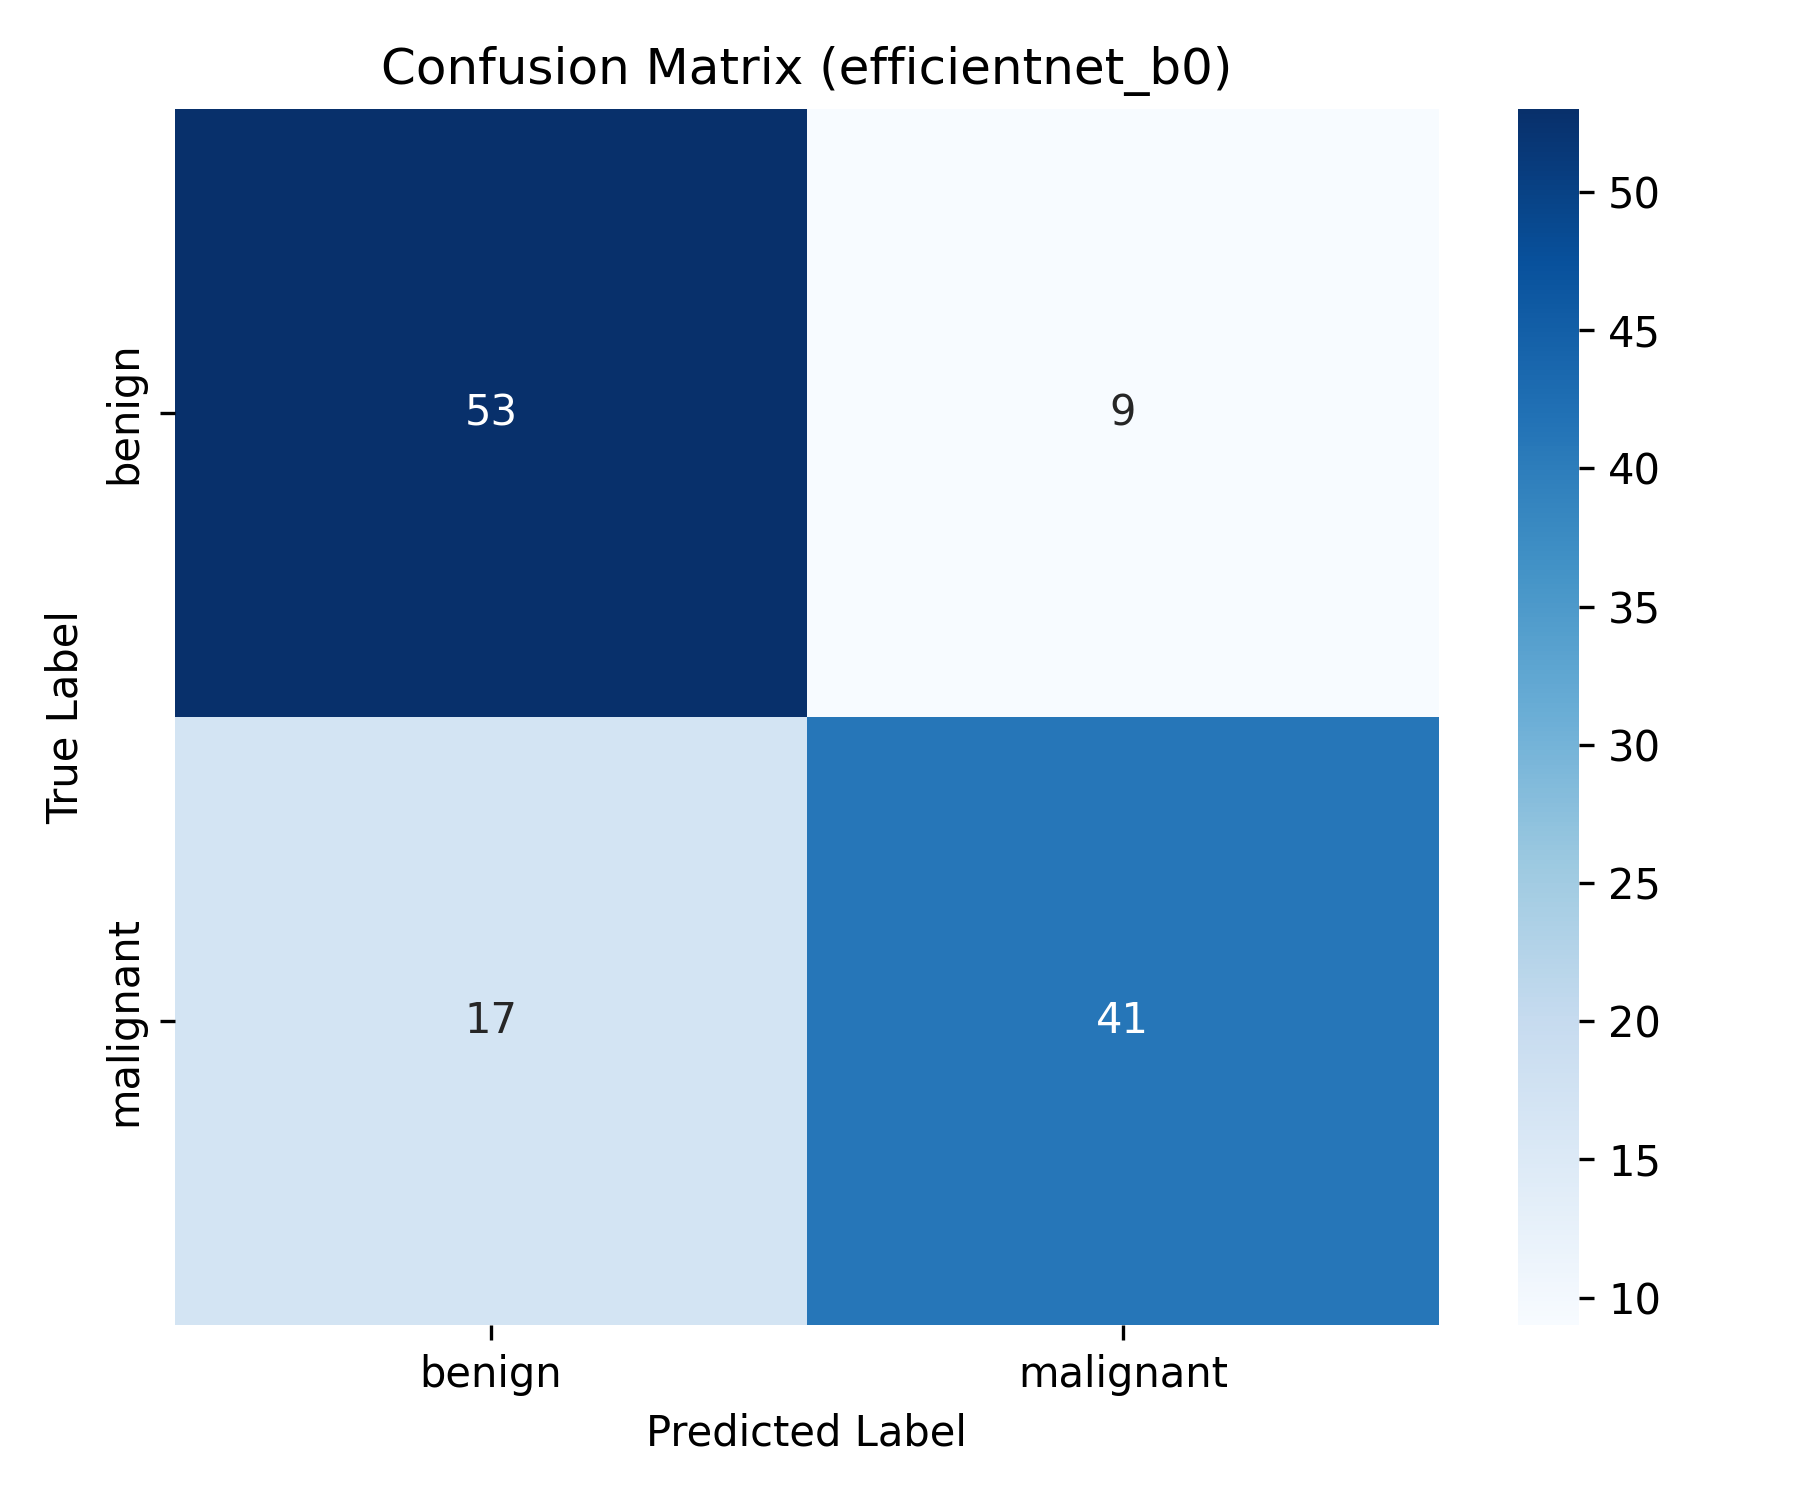

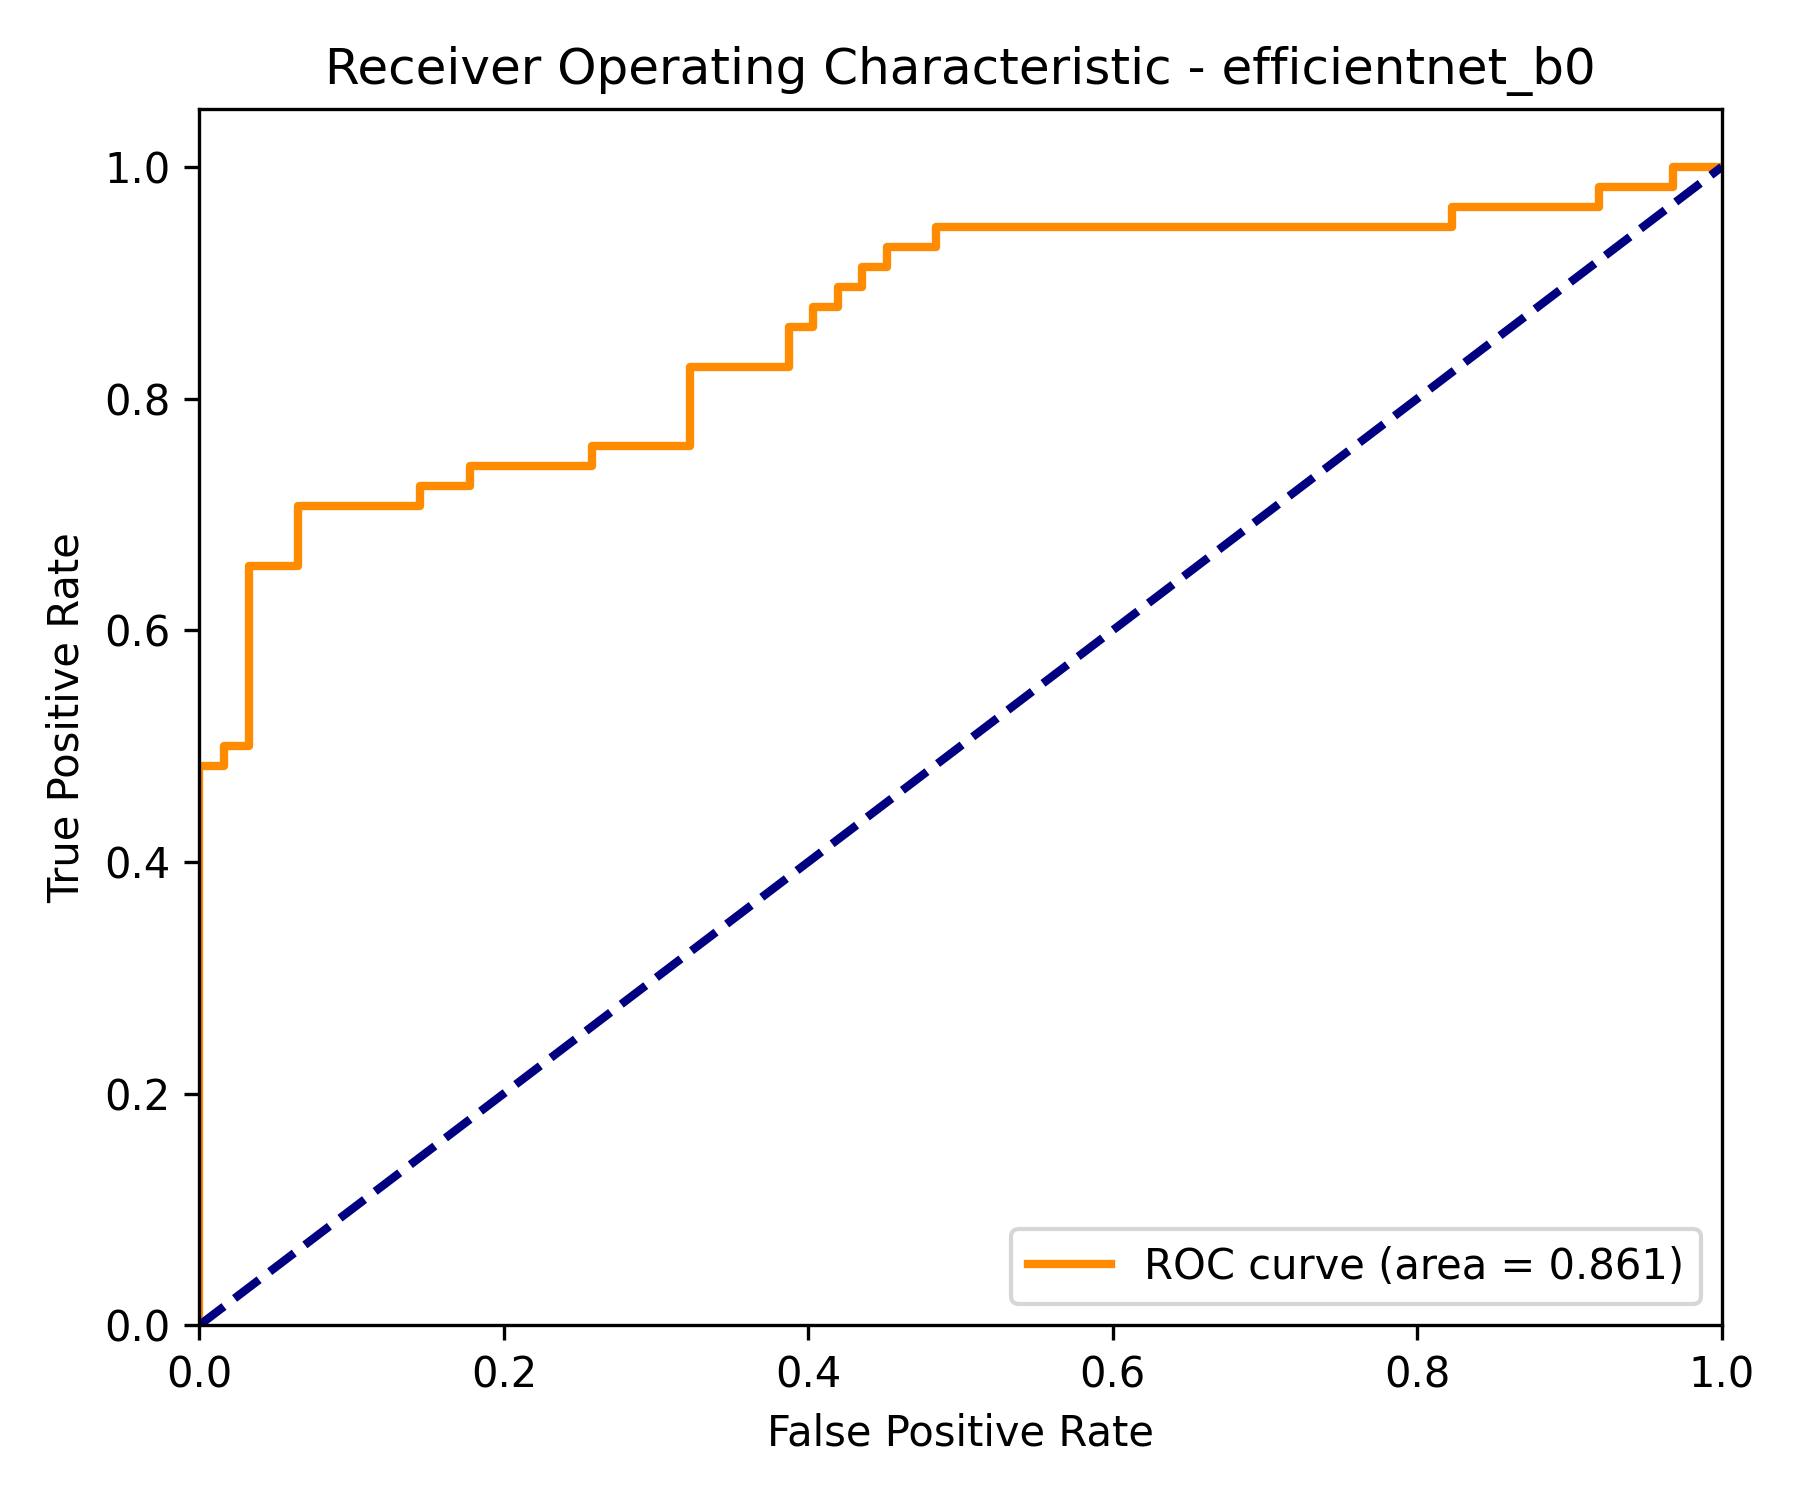

In [6]:
from IPython.display import Image, display

display(Image(filename="outputs/confusion_matrix.png", width=520))
display(Image(filename="outputs/roc_curve.png", width=520))

## 5. Interpretation

The current run confirms that the checkpoint, data loader, preprocessing, evaluator, and artifact writers operate together. It does **not** establish patient-independent generalisation because OASBUD and BrEaST subjects cross partitions and BUSI patient separation cannot be verified.

A defensible final experiment must recover original identifiers, create a subject-level manifest, freeze the test set before model selection, use predeclared repeated seeds and equal tuning budgets, save every prediction, and regenerate every table and figure from those saved records.

## Submission checklist

- [ ] Dataset licences, versions, checksums, exclusions, and label mapping recorded
- [ ] Every subject and all associated views/masks assigned to one partition
- [ ] Test manifest frozen before model selection
- [ ] Seeds, environment, configuration, and checkpoint hashes saved
- [ ] Per-image predictions retained for every reported run
- [ ] Uncertainty, calibration, failure cases, and subgroup/site limitations reported
- [ ] LaTeX, Word, slides, README, notebook, and website regenerated from the final evidence